# MODELO CALIBRADO

## Importar librerías

In [48]:
import sys
import mesa
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

## Corrección de posibles errores de ruta

In [49]:
np.random.seed(42)
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
if project_root not in sys.path:
    sys.path.append(project_root)

## Importamos modelo.py desde la carpeta modelo

In [50]:
from modelo.modelo import ModeloAnisi

## Imprimimos el título

In [51]:
print("=" * 60)
print("   FASE 1: OPTIMIZACIÓN MONTE CARLO - ESPAÑA 2024")
print("=" * 60)

   FASE 1: OPTIMIZACIÓN MONTE CARLO - ESPAÑA 2024


## Declaramos las variables y los rangos

In [52]:
POBLACION = 1000
SALARIO_REAL = 17.5    # Coste laboral neto
TARGET_PARO = 0.114    # 11.4% (INE)
TARGET_I3 = 1.10       # Tensión de consumo objetivo


RANGO_GA = [65_000_000, 85_000_000]
RANGO_C = [5.0, 7.5]
RANGO_ZB = [5.0, 14.0]


NUM_ITER = 2000
C_STD = 0.05

## Definimos la función crear_modelo

In [53]:
def crear_modelo(g_a, c, zb):
    return ModeloAnisi(
        t=0.30, j=1700.0, z_media=68.0, z_std=5.0, w_media=SALARIO_REAL, w_std=2.0,
        G_a=g_a, c_media=c, c_std=C_STD, zb_media=zb, zb_std=2.0,
        N_trabajadores=POBLACION, N_empresas=50, T_i_total=4800.0
    )

## Definimos la función calcular_error

In [54]:
def calcular_error(modelo):
    tasa_paro = 1.0 - (modelo.empleo_total / modelo.N)
    i3 = modelo.I3_agregado
    if i3 > 2.0 or i3 < 0.5 or np.isnan(i3): return 1000.0
    return (abs(tasa_paro - TARGET_PARO) * 500) + (abs(i3 - TARGET_I3) * 100)


## Código para la calibración

In [55]:
mejor_error = float('inf')
mejores_params = None

inicio = time.time()
for i in range(NUM_ITER):
    g_val = np.random.uniform(*RANGO_GA)
    c_val = np.random.uniform(*RANGO_C)
    z_val = np.random.uniform(*RANGO_ZB)
    
    if z_val >= SALARIO_REAL: continue # Condición w > zb
    
    try:
        modelo = crear_modelo(g_val, c_val, z_val)
        modelo.step()
        error = calcular_error(modelo)
        
        if error < mejor_error:
            mejor_error = error
            mejores_params = {'G_a': g_val, 'c': c_val, 'zb': z_val}
            paro_actual = (1 - modelo.empleo_total/POBLACION)*100
            print(f"Mejora (Iter {i}): Paro {paro_actual:.1f}% | I3 {modelo.I3_agregado:.3f} | Error {error:.2f}")
    except: continue


Mejora (Iter 0): Paro 9.4% | I3 1.006 | Error 19.40
Mejora (Iter 11): Paro 13.9% | I3 1.102 | Error 12.75
Mejora (Iter 124): Paro 12.7% | I3 1.056 | Error 10.94
Mejora (Iter 207): Paro 11.8% | I3 1.177 | Error 9.71
Mejora (Iter 325): Paro 11.4% | I3 1.167 | Error 6.69
Mejora (Iter 328): Paro 11.6% | I3 1.046 | Error 6.45
Mejora (Iter 375): Paro 11.5% | I3 1.072 | Error 3.25
Mejora (Iter 742): Paro 11.5% | I3 1.087 | Error 1.80


## Imprimimos el resultado 

In [56]:

print(f"\n✅ Optimización completada en {time.time()-inicio:.1f}s")
print("-" * 40)
print("RESULTADOS DE CALIBRACIÓN:")
print(f" > Gasto Público (G_a): {mejores_params['G_a']:,.0f}")
print(f" > Consumo (c):         {mejores_params['c']:.4f}")
print(f" > Prod. Casa (zb):     {mejores_params['zb']:.2f}")


✅ Optimización completada en 63.7s
----------------------------------------
RESULTADOS DE CALIBRACIÓN:
 > Gasto Público (G_a): 75,211,372
 > Consumo (c):         7.2121
 > Prod. Casa (zb):     9.35


# Exposición de los resultados mediante gráficas

## Imprimimos el título

In [57]:
print("=" * 60)
print("   FASE 2: ANÁLISIS DE ROBUSTEZ Y ESCENARIOS")
print("=" * 60)

   FASE 2: ANÁLISIS DE ROBUSTEZ Y ESCENARIOS


## Recibe los valores del código anterior e inicializa las variables

In [58]:
NUM_VALIDACION = 50
GA_OPTIMO = mejores_params['G_a']
C_OPTIMO  = mejores_params['c']
ZB_OPTIMO = mejores_params['zb']

## Se definen los escenarios

In [59]:
escenarios = {
    "1. España 2024 (Base)":   {"G_a": GA_OPTIMO,        "c_media": C_OPTIMO},
    "2. Austeridad (-20% G)": {"G_a": GA_OPTIMO * 0.80, "c_media": C_OPTIMO},
    "3. Consumismo (+20% c)": {"G_a": GA_OPTIMO,        "c_media": C_OPTIMO * 1.20}
}

## Comprobamos la robustez del modelo y calculamos para cada escenario

In [60]:
datos_consolidados = []

for nombre, cambios in escenarios.items():
    print(f"Simulando robustez: {nombre}...", end=" ")
    paros_temp, i3_temp, i1_temp = [], [], []
    
    for _ in range(NUM_VALIDACION):
        m = crear_modelo(cambios["G_a"], cambios["c_media"], ZB_OPTIMO)
        m.step()
        
        paros_temp.append((1 - m.empleo_total / POBLACION) * 100)
        i3_temp.append(m.I3_agregado)
        
        L_mercado = sum([t.horas_mercado for t in m.trabajadores])
        L_s = sum([t.L_s for t in m.trabajadores])
        i1_temp.append(L_mercado / L_s if L_s > 0 else 0)
    
    datos_consolidados.append({
        "Escenario": nombre,
        "Tasa Paro (%)": np.mean(paros_temp),
        "Indice I3": np.mean(i3_temp),
        "Indice I1 (Colocación)": np.mean(i1_temp)
    })
    print("✅")

Simulando robustez: 1. España 2024 (Base)... ✅
Simulando robustez: 2. Austeridad (-20% G)... ✅
Simulando robustez: 3. Consumismo (+20% c)... ✅


## Almacenamos los resultados en la carpeta data dentro del archivo resultados_finales_anisi.csv para facilitar su exportación

In [61]:
df_resultados = pd.DataFrame(datos_consolidados)
df_resultados.to_csv("../data/resultados_finales_anisi.csv", index=False)

## Se realiza el análisis de los datos generados en base a la teoría de Anisi

In [62]:
m_final = crear_modelo(GA_OPTIMO, C_OPTIMO, ZB_OPTIMO)
m_final.step()
L_mercado = sum([t.horas_mercado for t in m_final.trabajadores])
L_b = sum([t.L_b for t in m_final.trabajadores])
Valor_Mercado = L_mercado * 68.0
Valor_Domestico = L_b * ZB_OPTIMO
Peso_Oculto = (Valor_Domestico / (Valor_Mercado + Valor_Domestico)) * 100

## Imprimimos los resultados

In [63]:
print("\n" + "-" * 40)
print("ANÁLISIS ESTRUCTURAL (ESCENARIO BASE)")
print(f" > I1 (Colocación): {df_resultados.iloc[0]['Indice I1 (Colocación)']:.4f}")
print(f" > I3 (Frustración): {df_resultados.iloc[0]['Indice I3']:.4f}")
print(f" > PIB Oculto Est.: {Peso_Oculto:.2f}%")
print("-" * 40)



----------------------------------------
ANÁLISIS ESTRUCTURAL (ESCENARIO BASE)
 > I1 (Colocación): 0.7582
 > I3 (Frustración): 1.0964
 > PIB Oculto Est.: 14.27%
----------------------------------------


## Generamos los gráficos

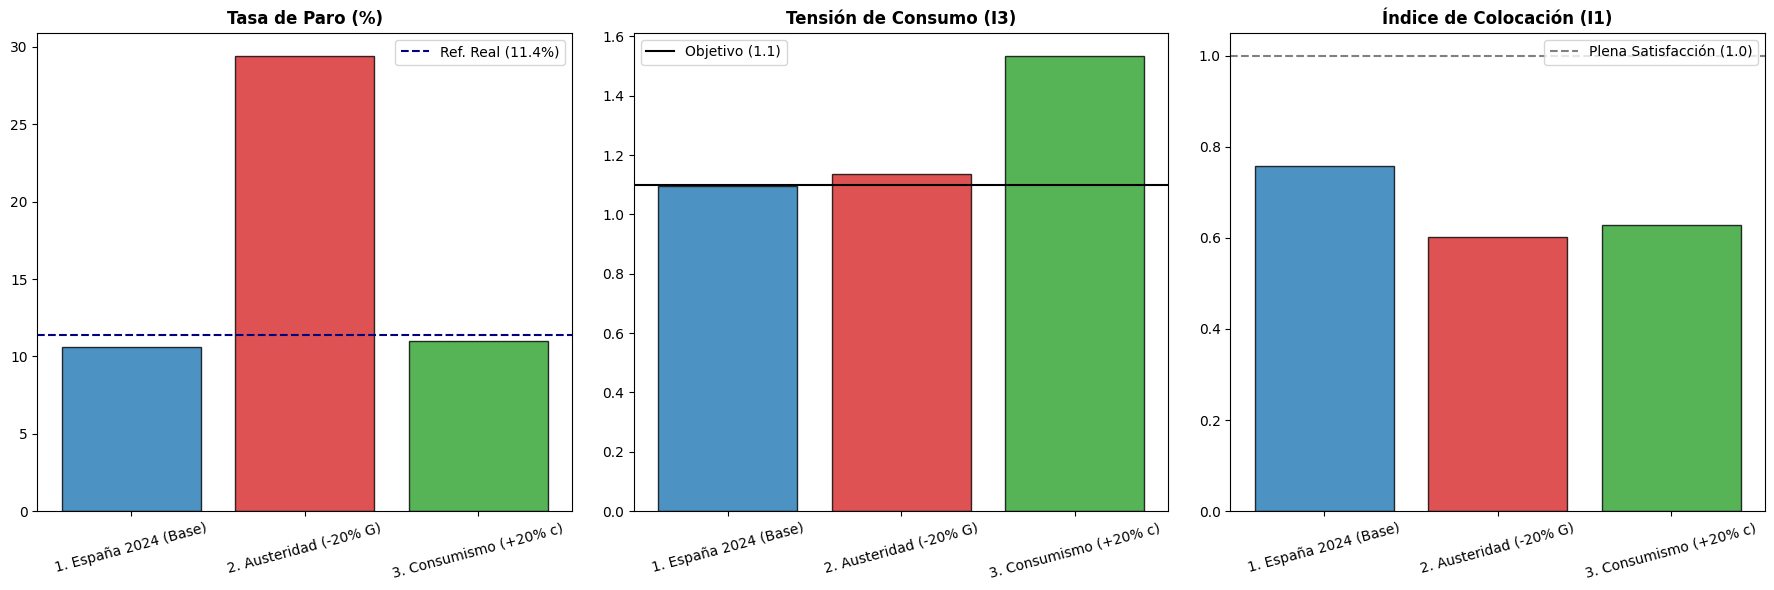

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#1f77b4', '#d62728', '#2ca02c']

# Gráfico de Paro
axes[0].bar(df_resultados["Escenario"], df_resultados["Tasa Paro (%)"], color=colors, alpha=0.8, edgecolor='black')
axes[0].set_title("Tasa de Paro (%)", fontweight='bold')
axes[0].axhline(y=TARGET_PARO*100, color='navy', linestyle='--', label=f"Ref. Real ({TARGET_PARO*100}%)")
axes[0].legend()

# Gráfico de I3
axes[1].bar(df_resultados["Escenario"], df_resultados["Indice I3"], color=colors, alpha=0.8, edgecolor='black')
axes[1].set_title("Tensión de Consumo (I3)", fontweight='bold')
axes[1].axhline(y=TARGET_I3, color='black', linestyle='-', label=f"Objetivo ({TARGET_I3})")
axes[1].legend()

# Gráfico de I1
axes[2].bar(df_resultados["Escenario"], df_resultados["Indice I1 (Colocación)"], color=colors, alpha=0.8, edgecolor='black')
axes[2].set_title("Índice de Colocación (I1)", fontweight='bold')
axes[2].axhline(y=1.0, color='gray', linestyle='--', label="Plena Satisfacción (1.0)")
axes[2].legend()

for ax in axes: ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()